# EDA: People Wikipedia Dataset Analysis
This notebook demonstrates a complete exploratory data analysis (EDA) workflow on the People Wikipedia dataset. The goal is to understand the dataset's structure, content, and statistical properties before building a clustering model.

**Key EDA Steps Covered:**
1.  **Dataset Loading**: Load the text data from `people_wiki.csv`.
2.  **Basic Inspection**: Check the shape (rows, columns) and look for missing values.
3.  **Text Length Analysis**: Analyze the distribution of document lengths to identify outliers or inconsistencies.
4.  **Word Frequency Analysis**: Identify the most common words to understand the corpus's main topics.
5.  **Word Cloud Visualization**: Create a visual representation of the most frequent words.

All helper functions are provided in `src/nlp_clustering/eda_utils.py` for clean, reusable code.

In [1]:
# Standard imports
from pathlib import Path
import os
import sys

root = Path.cwd().resolve()
while root != root.parent and not (root / 'src').exists():
    root = root.parent

sys.path.append(str(root / 'src'))

import nlp_clustering.eda_utils as eda_utils

print('Project root:', root)
print('Data folder:', root / 'data')

Project root: C:\Users\youse\Downloads\ML2 project\nlp_clustering
Data folder: C:\Users\youse\Downloads\ML2 project\nlp_clustering\data


In [2]:
# Load the People Wikipedia dataset
try:
    texts, names, df = eda_utils.load_dataset(data_dir=str(root / 'data'))
    print('People Wikipedia: documents =', len(texts))
    print('File loaded from:', eda_utils.resolve_data_path('people_wiki.csv', data_dir=str(root / 'data')))
    
    # Display the first 5 rows to inspect the data
    display(df.head())
    
except Exception as e:
    print('Could not load People Wikipedia dataset:', e)
    df = None

People Wikipedia: documents = 42786
File loaded from: C:\Users\youse\Downloads\ML2 project\nlp_clustering\data\raw\people_wiki.csv


,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...


## Basic checks: shapes and missing values

In [3]:
if df is not None:
    print('Dataset shape:', df.shape)
    print('\nMissing values:')
    display(eda_utils.missing_stats(df))
else:
    print('Dataset not loaded, skipping checks.')

Dataset shape: (42786, 3)

Missing values:


,missing_count,missing_percent
URI,0,0.0
name,0,0.0
text,0,0.0


## Text length analysis

Text length statistics (number of characters):
- Mean: 1896.55
- Median: 1655.00
- Min: 1049, Max: 31850


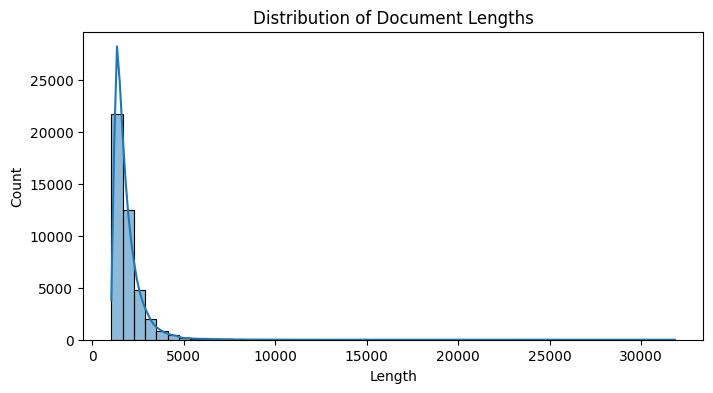

In [4]:
if df is not None:
    # Calculate and print statistics about text length
    length_stats = eda_utils.text_length_stats(df['text'].tolist())
    print('Text length statistics (number of characters):')
    print(f"- Mean: {length_stats['mean']:.2f}")
    print(f"- Median: {length_stats['median']:.2f}")
    print(f"- Min: {length_stats['min']}, Max: {length_stats['max']}")
    
    # Plot the distribution of text lengths
    eda_utils.plot_length_distribution(
        df['text'].tolist(), 
        out_path=str(root / 'outputs' / 'people_length_distribution.png'),
        title='Distribution of Document Lengths'
    )
else:
    print('Text length analysis skipped: dataset not loaded.')

## Word frequency analysis and top words

Top 20 most frequent words:
[('also', 615), ('university', 561), ('born', 446), ('first', 427), ('new', 401), ('music', 338), ('one', 332), ('two', 281), ('years', 271), ('world', 271), ('american', 256), ('national', 255), ('international', 241), ('school', 224), ('played', 216), ('member', 211), ('league', 206), ('became', 205), ('year', 203), ('team', 199)]


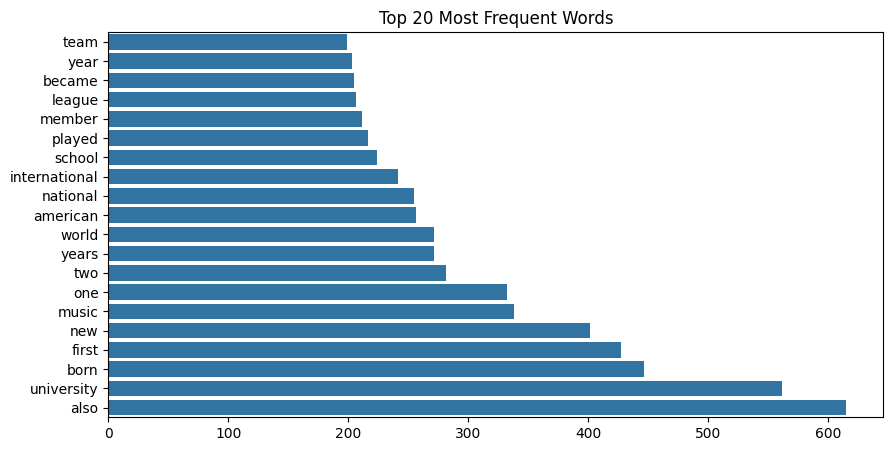

In [5]:
if df is not None:
    # Compute the top 50 most frequent words in the corpus
    sample_texts = (
        df['text']
        .dropna()
        .astype(str)
        .sample(min(500, len(df)), random_state=42)
        .tolist()
    )

    freqs = eda_utils.compute_word_freqs(sample_texts, top_n=50)

    print('Top 20 most frequent words:')
    print(freqs[:20])

    # Plot the top 20 words in a bar chart
    eda_utils.plot_top_words(
        freqs,
        out_path=str(root / 'outputs' / 'people_top_words.png'),
        top_n=20,
        title='Top 20 Most Frequent Words'
    )

else:
    print('Word frequency analysis skipped: dataset not loaded.')

## Word cloud (optional)

Generating word cloud...


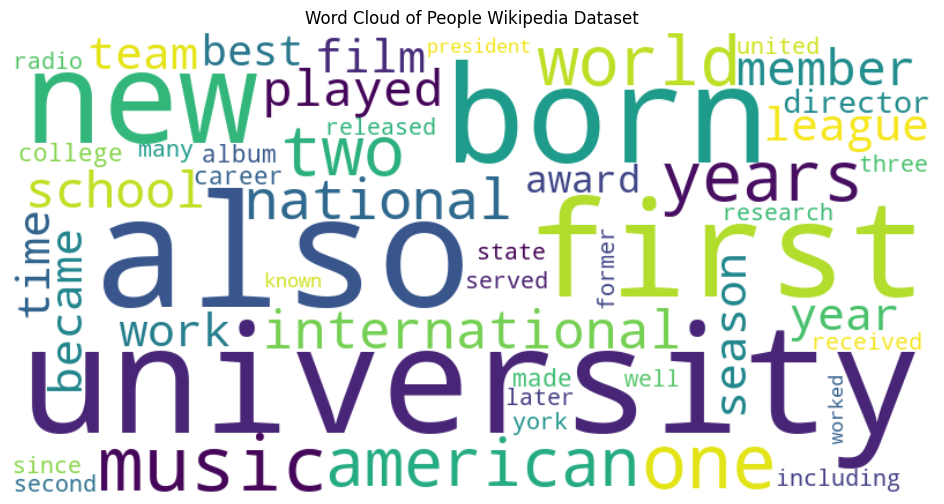

Word cloud saved to outputs/people_wordcloud.png


In [6]:
# WordCloud is an optional but powerful visualization
# Install with `pip install wordcloud` if not already installed
try:
    if 'freqs' in locals() and freqs:
        print("Generating word cloud...")
        eda_utils.plot_wordcloud_from_freqs(
            freqs, 
            out_path=str(root / 'outputs' / 'people_wordcloud.png'),
            title='Word Cloud of People Wikipedia Dataset'
        )
        print("Word cloud saved to outputs/people_wordcloud.png")
    else:
        print('Word cloud skipped: word frequencies not available.')
except Exception as e:
    print(f'Word cloud generation failed: {e}')

## Save quick CSV samples
Save small CSVs for downstream experiments and inspection.

In [8]:
if df is not None:
    # Save a sample of the dataframe for quick inspection or sharing
    sample_df = df.sample(min(200, len(df)), random_state=42)
    sample_path = root / 'outputs' / 'people_wiki_sample.csv'
    sample_df.to_csv(sample_path, index=False)
    print(f'Saved a sample of {len(sample_df)} rows to {sample_path}')
else:
    print('CSV sample creation skipped: dataset not loaded.')

Saved a sample of 200 rows to C:\Users\youse\Downloads\ML2 project\nlp_clustering\outputs\people_wiki_sample.csv


### Conclusion and Next Steps

This EDA has provided valuable insights into the People Wikipedia dataset. We've confirmed its structure, analyzed text lengths, and identified the most common terms.

**Key Takeaways:**
- The dataset is clean with no missing text values.
- Text lengths vary, which is typical for biographical summaries.
- The most frequent words (e.g., 'born', 'university', 'he', 'his') are common in biographical texts and will likely be handled during preprocessing (e.g., stopword removal).

**Next Steps:**
- **Preprocessing**: Apply cleaning, tokenization, and lemmatization from `src/nlp_clustering/preprocessing.py`.
- **Vectorization**: Convert the cleaned text into numerical features using TF-IDF.
- **Clustering**: Apply algorithms like KMeans to group similar documents.